In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

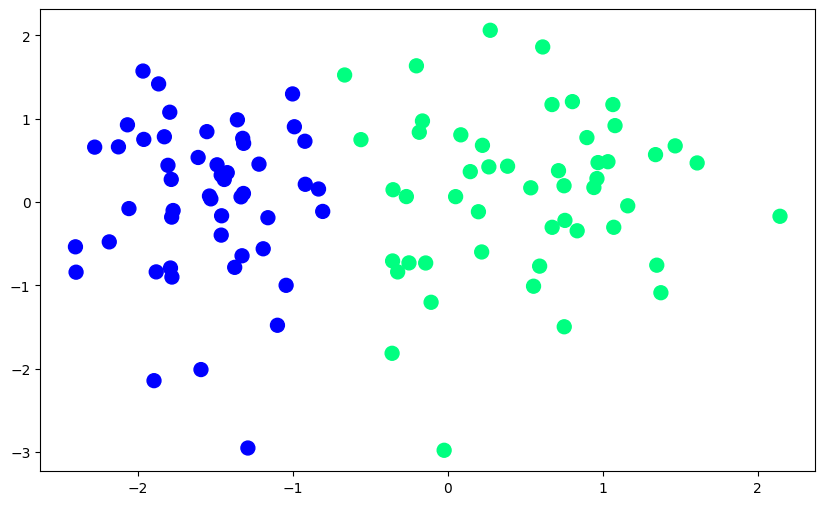

In [2]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [3]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [4]:
lor.coef_, lor.intercept_

(array([[3.50144121, 0.02773483]]), array([2.25106636]))

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [88]:
def GD_classifier(X, y, epochs=1000, lr=0.1):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    m = X.shape[0]

    for i in range(epochs):
        z = np.dot(X, weights)
        y_pred = sigmoid(z)

        gradient = np.dot((y - y_pred), X) / m
        weights = weights + lr * gradient

        if i % 200 == 0:
            loss = -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
            print(f"Epoch {i}, Loss: {loss}")

    return weights[1:], weights[0]

In [20]:
# X.shape
# np.insert(X, 0, 1, axis=1)

In [91]:
my_coeff_, my_intercept_ = GD_classifier(X, y, epochs=2000)

Epoch 0, Loss: 0.4252383347721356
Epoch 200, Loss: 0.12782135775956552
Epoch 400, Loss: 0.09659295573958147
Epoch 600, Loss: 0.08090468448492077
Epoch 800, Loss: 0.07100006152817499
Epoch 1000, Loss: 0.06402294589917626
Epoch 1200, Loss: 0.05876893259550489
Epoch 1400, Loss: 0.054629109502899
Epoch 1600, Loss: 0.05125817174887874
Epoch 1800, Loss: 0.04844387170710332


In [92]:
my_coeff_ , my_intercept_

(array([5.50981101, 0.11766229]), 3.484182664269018)

## visual comparision

In [76]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [77]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

In [93]:
m = -(my_coeff_[0]/my_coeff_[1])
b = -(my_intercept_/my_coeff_[1])

In [94]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

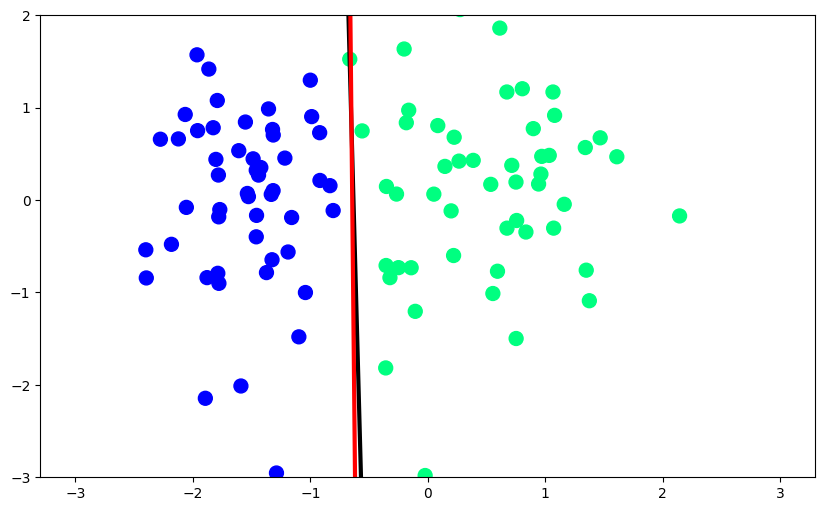

In [95]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()